# Network Intrusion Detection: Four Models at Scale

Every second, millions of network connections traverse the internet. Most are legitimate — browsing, file transfers, logins. Some are attacks.

The **KDD Cup 99** dataset comes from a 1999 DARPA competition: ~500,000 simulated network connections from a US Air Force LAN, each labeled as normal traffic or one of 22 attack types (SYN floods, port scans, buffer overflows, and more).

Your goal: train a classifier that distinguishes normal connections from attacks using 41 features extracted per connection.

## What's different from the previous projects
- **~500k rows** — comparable scale to Covertype
- **Inverted imbalance** — attacks are the *majority* (~80%), not the minority
- **3 categorical + 38 numeric features** — simple encoding problem
- **Easy to classify** — performance will be high; the interesting part is *why* and *where each model struggles*

## What you'll learn
- How inverted class imbalance (`pos_weight < 1`) changes model behavior
- How to decode byte-string data (a quirk of Python 2-era datasets)
- How Random Forest feature importances reveal the actual signal in network data

In [12]:
import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'

import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_kddcup99
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

from xgboost import XGBClassifier

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

if torch.cuda.is_available():
    device = 'cuda'
elif torch.backends.mps.is_available():
    device = 'mps'
else:
    device = 'cpu'

print('Libraries loaded!')
print(f'Using device: {device}')

Libraries loaded!
Using device: mps


## Step 1: Load the Data

`fetch_kddcup99()` downloads the dataset automatically and caches it locally. By default it loads the **10% subset** — ~494,000 connections, small enough to train all four models in a few minutes.

**Features (41 total):**
- **3 categorical**: `protocol_type` (tcp/udp/icmp), `service` (~66 types like http, ftp, smtp), `flag` (~11 connection states)
- **38 continuous**: duration, byte counts, error rates, login flags, host-level statistics

**Target**: `normal.` vs 22 attack types. We'll collapse to binary: normal=0, attack=1.

**Byte strings**: This dataset was created in the Python 2 era. Text values come as `b'tcp'` instead of `'tcp'`. One decode step fixes it.

In [13]:
print('Downloading KDD Cup 99 (10% subset, ~494k rows)...')
kdd = fetch_kddcup99(as_frame=True)  # percent10=True is the default

df = kdd.data.copy()
labels_raw = pd.Series(kdd.target).copy()

# Decode byte strings — Python 2-era artifact
def to_str(x):
    return x.decode('utf-8') if isinstance(x, bytes) else str(x)

# include both 'object' and 'str' to cover pandas 2/3 (object) and pandas 4 (StringDtype)
for col in df.select_dtypes(include=['object', 'str']).columns:
    df[col] = df[col].apply(to_str)
labels_raw = labels_raw.apply(to_str)

# sklearn returns all columns as byte strings — convert numeric-looking ones to actual numbers
# errors='ignore' leaves non-numeric strings (tcp, http, SF) untouched
df = df.apply(pd.to_numeric, errors='ignore')

print(f'Shape: {df.shape}')
print(f'Columns: {list(df.columns)}')
df.head(50)

ValueError: invalid error value specified

## Step 2: Explore the Data

Before modeling, look at the class distribution. This dataset is unusual compared to the last two projects:

- **Hospital readmission**: 11% positive (readmitted) — minority problem
- **Bank marketing**: 11% positive (subscribed) — minority problem
- **Network intrusion**: ~80% positive (attack) — *majority* problem

A naive model that predicts "attack" for everything gets ~80% accuracy — but completely fails to identify normal traffic. `class_weight='balanced'` handles both directions.

In [ ]:
cat_cols = df.select_dtypes(include=['object', 'str']).columns.tolist()
num_cols = df.select_dtypes(exclude=['object', 'str']).columns.tolist()
print(f'Categorical columns: {cat_cols}')
print(f'Numeric columns: {len(num_cols)}')
print()

normal_n = (labels_raw == 'normal.').sum()
attack_n = (labels_raw != 'normal.').sum()

print('Binary class distribution:')
print(f'  Normal: {normal_n:>7,}  ({normal_n/len(labels_raw):.1%})')
print(f'  Attack: {attack_n:>7,}  ({attack_n/len(labels_raw):.1%})')
print()
print('Attack type breakdown:')
print(labels_raw[labels_raw != 'normal.'].value_counts())

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Binary class distribution
axes[0].bar(['Normal', 'Attack'], [normal_n, attack_n], color=['steelblue', 'salmon'])
axes[0].set_title('Binary class distribution')
axes[0].set_ylabel('Count')
for i, v in enumerate([normal_n, attack_n]):
    axes[0].text(i, v + 3000, f'{v/len(labels_raw):.1%}', ha='center', fontsize=11)

# Protocol type
df['protocol_type'].value_counts().plot(kind='bar', ax=axes[1], color='steelblue')
axes[1].set_title('Protocol type distribution')
axes[1].tick_params(axis='x', rotation=0)

# Top attack types
attack_counts = labels_raw[labels_raw != 'normal.'].value_counts().head(8)
attack_counts.plot(kind='barh', ax=axes[2], color='salmon')
axes[2].set_title('Top attack types')
axes[2].set_xlabel('Count')

plt.tight_layout()
plt.show()

print()
print('smurf. (ICMP amplification) and neptune. (SYN flood) are classic DoS attacks.')
print('These two alone account for ~78% of all traffic — easy to detect from byte patterns.')

## Step 3: Clean and Encode

Three steps:

1. **Binary target**: 23 attack labels → 0/1
2. **One-hot encode** `protocol_type`, `service`, `flag`
3. **Result**: 38 numeric + ~2 protocol + ~65 service + ~10 flag ≈ **115 features total**

The `service` column has 66 unique values — that's more dummies than `protocol_type` (3) and `flag` (11) combined. Each one becomes a binary column: "was this an HTTP connection?", "was this an FTP connection?", etc.

In [ ]:
data = df.copy()

# Binary target: normal=0, any attack=1
data['target'] = (labels_raw != 'normal.').astype(int).values

# One-hot encode the 3 categorical columns
data = pd.get_dummies(data, columns=['protocol_type', 'service', 'flag'])

# Convert any bool columns to int (newer pandas returns bool from get_dummies)
bool_cols = data.select_dtypes(include='bool').columns
data[bool_cols] = data[bool_cols].astype(int)

print(f'Shape after encoding: {data.shape}')
print(f'All dtypes numeric: {(data.dtypes != object).all()}')
print(f'\nAttack rate: {data["target"].mean():.1%}')
data.head()

## Step 4: Train/Test Split + Scale

Same pipeline as before: 80/20 split stratified by target, then `StandardScaler` fit on training data only.

With ~395k training samples, every model has more than enough data to learn from.

In [ ]:
X = data.drop(columns=['target'])
y = data['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f'Training samples: {len(X_train):,}')
print(f'Test samples:     {len(X_test):,}')
print(f'Features:         {X_train.shape[1]}')
print(f'Attack rate in test: {y_test.mean():.1%}')
print()
print('class_weight="balanced" will upweight the minority *normal* class (20%).')
print('This is the opposite of the readmission/bank projects where positives were rare.')

## Step 5: Logistic Regression

The linear baseline. With 115 features, LR draws hyperplanes in 115-dimensional space. Network traffic patterns are largely threshold-based ("if src_bytes=0 AND protocol=icmp → smurf attack"), which linear models can approximate but not perfectly capture.

In [14]:
print('Training Logistic Regression...')
lr = LogisticRegression(class_weight='balanced', max_iter=1000)
lr.fit(X_train_scaled, y_train)
lr_preds = lr.predict(X_test_scaled)

print(f'Accuracy: {accuracy_score(y_test, lr_preds):.1%}')
print()
print(classification_report(y_test, lr_preds, target_names=['Normal', 'Attack']))

Training Logistic Regression...
Accuracy: 99.8%

              precision    recall  f1-score   support

      Normal       0.99      1.00      0.99     19456
      Attack       1.00      1.00      1.00     79349

    accuracy                           1.00     98805
   macro avg       1.00      1.00      1.00     98805
weighted avg       1.00      1.00      1.00     98805



## Step 6: Random Forest

Tree-based models are naturally suited to network feature patterns — rules like "if protocol=icmp AND dst_bytes=0 → 99% chance of smurf attack" are exactly what decision trees learn.

Unlike the readmission/bank projects where trees needed feature engineering to shine, the raw network features already encode these thresholds cleanly.

In [15]:
print('Training Random Forest (may take ~1-2 min)...')
rf = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42, n_jobs=-1)
rf.fit(X_train_scaled, y_train)
rf_preds = rf.predict(X_test_scaled)

print(f'Accuracy: {accuracy_score(y_test, rf_preds):.1%}')
print()
print(classification_report(y_test, rf_preds, target_names=['Normal', 'Attack']))

Training Random Forest (may take ~1-2 min)...
Accuracy: 100.0%

              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     19456
      Attack       1.00      1.00      1.00     79349

    accuracy                           1.00     98805
   macro avg       1.00      1.00      1.00     98805
weighted avg       1.00      1.00      1.00     98805



## Step 7: Neural Network

Same MLP architecture as the bank marketing project — but with one key difference: `pos_weight < 1`.

Recall that in previous projects, `pos_weight > 1` amplified the cost of missing the rare positive class. Here attacks are the **majority**, so:

```
pos_weight = n_normal / n_attack  ≈  0.25
```

Setting it below 1 **down-weights** the majority attack class in the loss, which forces the model to also learn normal traffic patterns instead of predicting attack for everything.

This is mathematically equivalent to `class_weight='balanced'` in sklearn.

In [16]:
class IntrusionDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y.values, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


train_dataset = IntrusionDataset(X_train_scaled, y_train)
test_dataset  = IntrusionDataset(X_test_scaled,  y_test)

train_loader = DataLoader(train_dataset, batch_size=512, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=512, shuffle=False)

print(f'Training batches per epoch: {len(train_loader)}')
print(f'Input features: {X_train_scaled.shape[1]}')

Training batches per epoch: 772
Input features: 118


In [17]:
class IntrusionMLP(nn.Module):
    def __init__(self, input_size):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(input_size, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),

            nn.Linear(64, 1),
        )

    def forward(self, x):
        return self.network(x).squeeze(1)


model = IntrusionMLP(X_train_scaled.shape[1]).to(device)
total_params = sum(p.numel() for p in model.parameters())
print(model)
print(f'\nTotal parameters: {total_params:,}')

IntrusionMLP(
  (network): Sequential(
    (0): Linear(in_features=118, out_features=256, bias=True)
    (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=256, out_features=128, bias=True)
    (5): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.2, inplace=False)
    (8): Linear(in_features=128, out_features=64, bias=True)
    (9): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (10): ReLU()
    (11): Linear(in_features=64, out_features=1, bias=True)
  )
)

Total parameters: 72,577


In [18]:
# pos_weight < 1 because attacks (positive=1) are the majority
# This down-weights attacks so the model also learns to detect normal traffic
pos_weight_val = (y_train == 0).sum() / (y_train == 1).sum()
print(f'pos_weight = {pos_weight_val:.3f}  (< 1 because attacks are the majority)')

pos_weight = torch.tensor([pos_weight_val], dtype=torch.float32).to(device)
criterion  = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer  = optim.Adam(model.parameters(), lr=1e-3)

train_losses, val_losses = [], []
train_accs,   val_accs   = [], []
n_epochs = 30

for epoch in range(n_epochs):
    model.train()
    batch_losses, correct, total = [], 0, 0

    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        logits = model(X_batch)
        loss   = criterion(logits, y_batch)
        loss.backward()
        optimizer.step()
        batch_losses.append(loss.item())
        preds    = (torch.sigmoid(logits) > 0.5).float()
        correct += (preds == y_batch).sum().item()
        total   += len(y_batch)

    train_losses.append(np.mean(batch_losses))
    train_accs.append(correct / total)

    model.eval()
    val_batch_losses, val_correct, val_total = [], 0, 0

    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            logits = model(X_batch)
            loss   = criterion(logits, y_batch)
            val_batch_losses.append(loss.item())
            preds       = (torch.sigmoid(logits) > 0.5).float()
            val_correct += (preds == y_batch).sum().item()
            val_total   += len(y_batch)

    val_losses.append(np.mean(val_batch_losses))
    val_accs.append(val_correct / val_total)

    if (epoch + 1) % 5 == 0:
        print(f'Epoch {epoch+1:3d}/{n_epochs} | '
              f'Train Loss: {train_losses[-1]:.4f} | '
              f'Val Loss: {val_losses[-1]:.4f} | '
              f'Val Acc: {val_accs[-1]:.1%}')

pos_weight = 0.245  (< 1 because attacks are the majority)
Epoch   5/30 | Train Loss: 0.0011 | Val Loss: 0.0016 | Val Acc: 99.9%
Epoch  10/30 | Train Loss: 0.0009 | Val Loss: 0.0016 | Val Acc: 99.9%
Epoch  15/30 | Train Loss: 0.0008 | Val Loss: 0.0015 | Val Acc: 99.9%
Epoch  20/30 | Train Loss: 0.0008 | Val Loss: 0.0017 | Val Acc: 100.0%
Epoch  25/30 | Train Loss: 0.0006 | Val Loss: 0.0017 | Val Acc: 99.9%
Epoch  30/30 | Train Loss: 0.0006 | Val Loss: 0.0014 | Val Acc: 99.9%


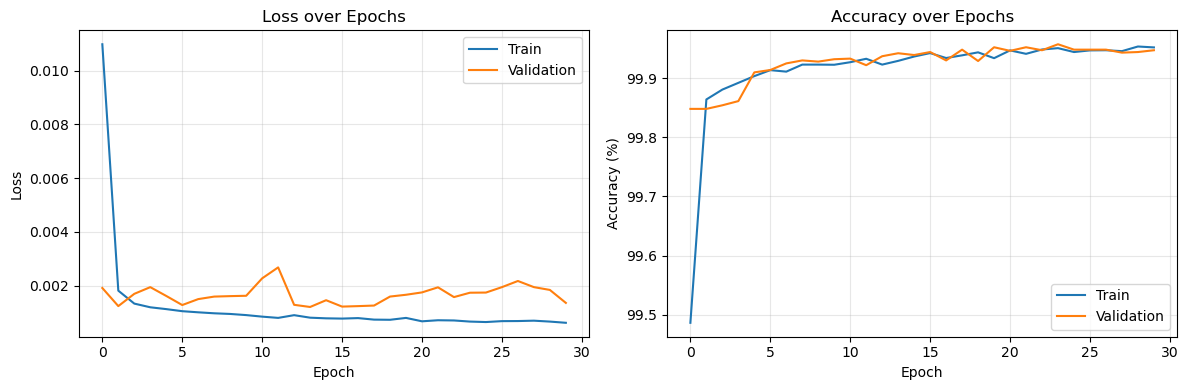

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(train_losses, label='Train')
axes[0].plot(val_losses,   label='Validation')
axes[0].set_title('Loss over Epochs')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot([a * 100 for a in train_accs], label='Train')
axes[1].plot([a * 100 for a in val_accs],   label='Validation')
axes[1].set_title('Accuracy over Epochs')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Step 8: XGBoost

XGBoost's `scale_pos_weight` is the same lever as `pos_weight` in the neural net — it adjusts how much the model cares about the positive class (attacks).

Since attacks are the majority here, `scale_pos_weight < 1` down-weights them — just like setting `pos_weight = 0.25` in the neural net.

In [20]:
print('Training XGBoost...')
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

xgb = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    verbosity=0,
    n_jobs=-1,
)
xgb.fit(X_train_scaled, y_train)
xgb_preds = xgb.predict(X_test_scaled)

print(f'Accuracy: {accuracy_score(y_test, xgb_preds):.1%}')
print()
print(classification_report(y_test, xgb_preds, target_names=['Normal', 'Attack']))

Training XGBoost...
Accuracy: 100.0%

              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     19456
      Attack       1.00      1.00      1.00     79349

    accuracy                           1.00     98805
   macro avg       1.00      1.00      1.00     98805
weighted avg       1.00      1.00      1.00     98805



## Step 9: Compare All Four Models

With a dataset where dominant attacks (smurf, neptune) are trivially easy to detect, all models should score high. The interesting question is **where each one fails** — look at the normal class recall in the confusion matrices.

In [21]:
# Collect neural net predictions
model.eval()
all_logits = []
with torch.no_grad():
    for X_batch, _ in test_loader:
        logits = model(X_batch.to(device))
        all_logits.append(logits.cpu())

nn_probs = torch.sigmoid(torch.cat(all_logits)).numpy()
nn_preds = (nn_probs > 0.5).astype(int)

# Print all four classification reports
for name, preds in [
    ('Logistic Regression',  lr_preds),
    ('Random Forest',        rf_preds),
    ('Neural Network (MLP)', nn_preds),
    ('XGBoost',              xgb_preds),
]:
    print(f'=== {name} ===')
    print(classification_report(y_test, preds, target_names=['Normal', 'Attack']))

=== Logistic Regression ===
              precision    recall  f1-score   support

      Normal       0.99      1.00      0.99     19456
      Attack       1.00      1.00      1.00     79349

    accuracy                           1.00     98805
   macro avg       1.00      1.00      1.00     98805
weighted avg       1.00      1.00      1.00     98805

=== Random Forest ===
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     19456
      Attack       1.00      1.00      1.00     79349

    accuracy                           1.00     98805
   macro avg       1.00      1.00      1.00     98805
weighted avg       1.00      1.00      1.00     98805

=== Neural Network (MLP) ===
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     19456
      Attack       1.00      1.00      1.00     79349

    accuracy                           1.00     98805
   macro avg       1.00      1.00      1.00     9

In [22]:
# Summary accuracy bar chart
results = {
    'Logistic Regression': accuracy_score(y_test, lr_preds),
    'Random Forest':        accuracy_score(y_test, rf_preds),
    'Neural Network':       accuracy_score(y_test, nn_preds),
    'XGBoost':              accuracy_score(y_test, xgb_preds),
}

print('=== Accuracy Comparison ===')
for name, acc in sorted(results.items(), key=lambda x: x[1], reverse=True):
    bar = '█' * int(acc * 40)
    print(f'{name:<22} {acc:.1%}  {bar}')

=== Accuracy Comparison ===
Random Forest          100.0%  ███████████████████████████████████████
XGBoost                100.0%  ███████████████████████████████████████
Neural Network         99.9%  ███████████████████████████████████████
Logistic Regression    99.8%  ███████████████████████████████████████


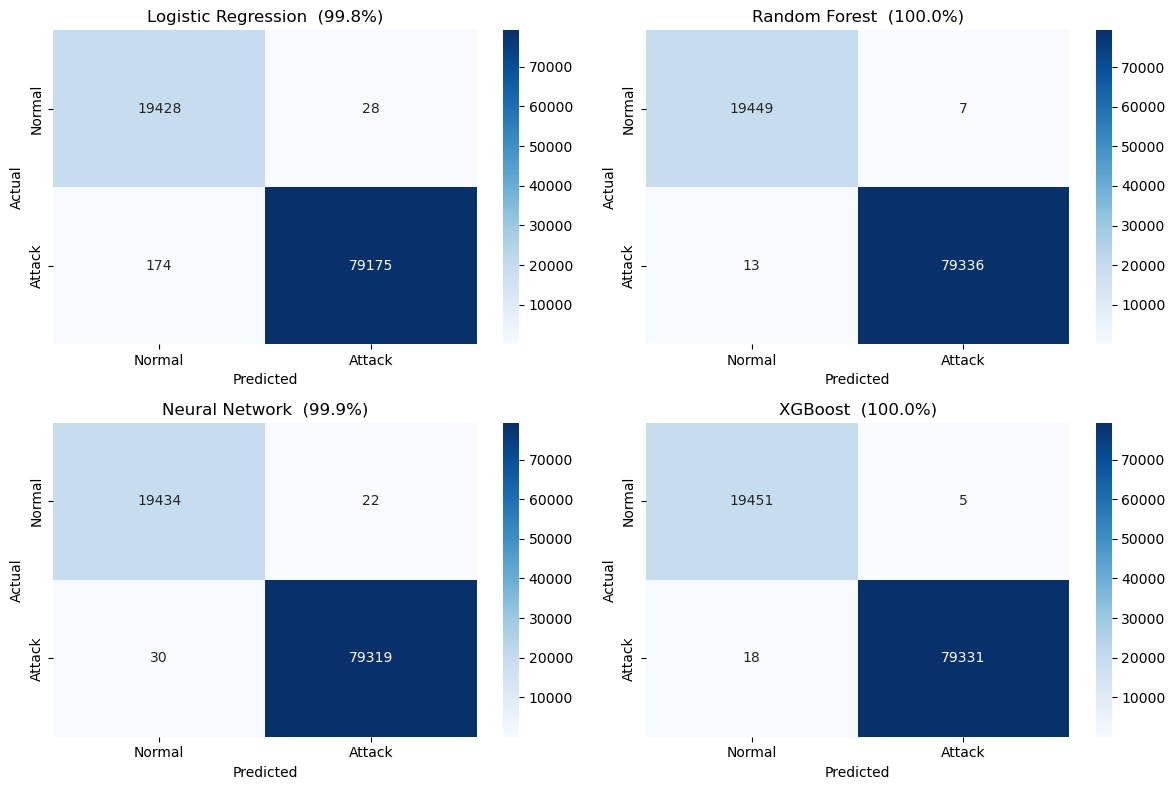

In [23]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for ax, preds, title in zip(
    axes,
    [lr_preds, rf_preds, nn_preds, xgb_preds],
    ['Logistic Regression', 'Random Forest', 'Neural Network', 'XGBoost']
):
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Normal', 'Attack'],
                yticklabels=['Normal', 'Attack'])
    acc = accuracy_score(y_test, preds)
    ax.set_title(f'{title}  ({acc:.1%})')
    ax.set_ylabel('Actual')
    ax.set_xlabel('Predicted')

plt.tight_layout()
plt.show()

## Step 10: Feature Importance

Which network features actually drive the classification? The answer reveals what makes smurf and neptune attacks trivially detectable — and hints at why rarer attacks are much harder.

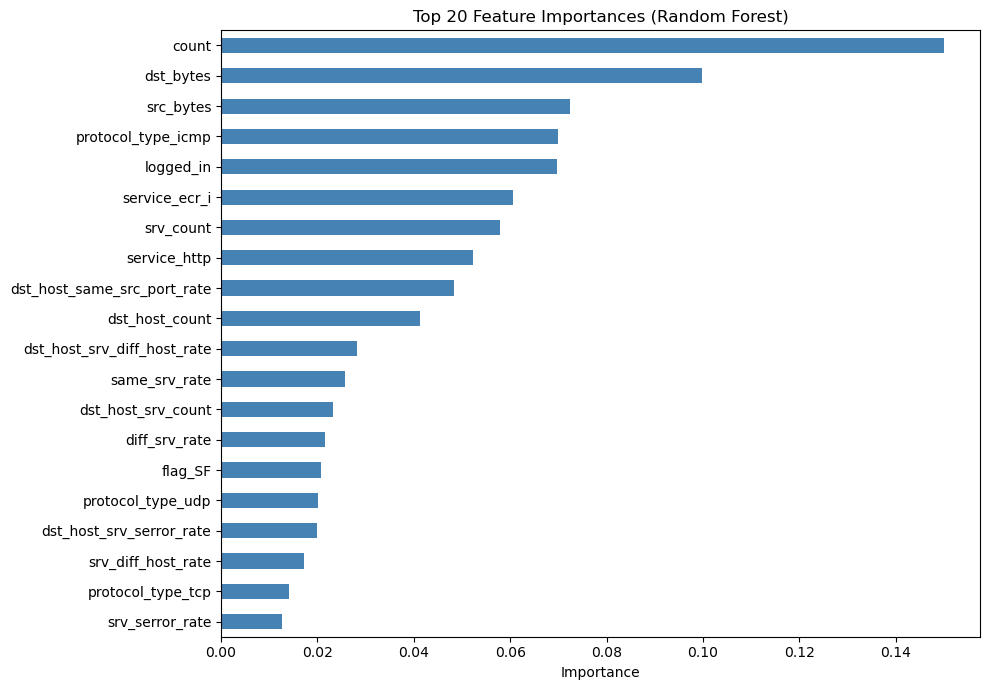

Top 10 most important features:
  count                                    0.1500
  dst_bytes                                0.0997
  src_bytes                                0.0724
  protocol_type_icmp                       0.0699
  logged_in                                0.0696
  service_ecr_i                            0.0605
  srv_count                                0.0578
  service_http                             0.0523
  dst_host_same_src_port_rate              0.0483
  dst_host_count                           0.0413


In [24]:
feature_names = X.columns.tolist()
importances = pd.Series(rf.feature_importances_, index=feature_names).sort_values(ascending=False)

plt.figure(figsize=(10, 7))
importances.head(20).sort_values().plot(kind='barh', color='steelblue')
plt.title('Top 20 Feature Importances (Random Forest)')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

print('Top 10 most important features:')
for feat, imp in importances.head(10).items():
    print(f'  {feat:<40} {imp:.4f}')

## What You Built

A four-model intrusion detection system on 494k real network connection records:

1. **Loaded** the KDD Cup 99 dataset via sklearn — no SSL issues, no manual downloads
2. **Decoded** Python 2 byte strings into regular strings
3. **Explored** an *inverted* class imbalance where attacks are the majority
4. **Encoded** 3 categorical columns with one-hot encoding → ~115 total features
5. **Applied** `class_weight='balanced'` / `pos_weight < 1` — same concept, opposite direction vs. previous projects
6. **Trained** all four models and compared them on the same test split
7. **Interpreted** which network features carry the most signal

## Why Performance Is High

KDD Cup 99 is considered a "solved" benchmark — smurf and neptune attacks together make up ~78% of traffic and leave unmistakable signatures in `src_bytes`, `dst_bytes`, and `protocol_type`. Any model that learns these simple thresholds gets high accuracy.

The real challenge in modern network security is **rare, novel, and stealthy attacks** — which are almost absent from this dataset.

## Things to Try

1. **Filter to rare attack types** — drop smurf and neptune, retrain. How does accuracy change when easy attacks are removed?
2. **Multiclass** — predict the actual attack category (DoS / Probe / R2L / U2R / normal) instead of binary. Use `CrossEntropyLoss` and see which category each model struggles with most
3. **Remove `pos_weight`** from the neural net — watch what happens to normal recall. This shows exactly what happens when you ignore imbalance
4. **Try `src_bytes` alone** — a single-feature logistic regression. How much of the signal is in that one column?
5. **XGBoost depth** — try `max_depth=3` vs `max_depth=8`. Does deeper help, or is the data clean enough that shallow trees suffice?